# Regression with statsmodels in Python

In [10]:
# Importing pandas
import pandas as pd

# Importing the course arrays
taiwan = pd.read_csv("taiwan_real_estate2.csv")

## 📊 Resumo do Código - Previsão de Preços de Imóveis

### 🎯 Objetivo
Utilizar um modelo de regressão linear para prever o preço de imóveis em Taiwan com base no número de lojas de conveniência próximas (`n_convenience`).

---

### ⚙️ O que o código faz
1. Carrega um dataset real de imóveis
2. Seleciona a variável explicativa (`n_convenience`)
3. Usa um modelo treinado para prever os preços
4. Adiciona as previsões ao DataFrame original

---

### 🧠 Resultado
Gera um novo dataset contendo:
- Dados reais
- Preço real NT$ (`price_twd_msq`)
- Preço previsto NT$ (`price_twd_msq_pred`)

---

### 🚀 Objetivo final
Comparar valores reais vs previstos para:
- Avaliar a qualidade do modelo
- Entender o comportamento dos preços
- Apoiar decisões baseadas em dados

---

### 💡 Conceito-chave
Transformar dados em **insights preditivos** usando Machine Learning.

_Add your notes here_

In [11]:
import pandas as pd
# carregar dados reais
df = pd.read_csv('taiwan_real_estate2.csv')
df.head(3)

,dist_to_mrt_m,n_convenience,house_age_years,price_twd_msq
0,84.87882,10,30 to 45,11.467474
1,306.59470,9,15 to 30,12.768533
2,561.98450,5,0 to 15,14.311649


### 🎯 Objetivo
Utilizar um modelo de regressão linear para prever o preço de imóveis com base no número de lojas de conveniência próximas (`n_convenience`).

In [12]:
# ==============================
# 1. TREINAR O MODELO
import statsmodels.formula.api as smf

modelo = smf.ols(
    'price_twd_msq ~ n_convenience',
    data=df
).fit()

# ==============================
# 2. FAZER PREVISÕES
price_twd_msq_pred = modelo.predict(df)

# ==============================
# 3. CRIAR DATAFRAME FINAL
prediction_data = df.assign(
    price_twd_msq_pred=price_twd_msq_pred
)

# ==============================
# 4. VISUALIZAR
print(prediction_data.head())

   dist_to_mrt_m  n_convenience house_age_years  price_twd_msq  \
0       84.87882             10        30 to 45      11.467474   
1      306.59470              9        15 to 30      12.768533   
2      561.98450              5         0 to 15      14.311649   
3      561.98450              5         0 to 15      16.580938   
4      390.56840              5         0 to 15      13.040847   

   price_twd_msq_pred  
0           16.205035  
1           15.406955  
2           12.214636  
3           12.214636  
4           12.214636  


### Analise do modelo 
Nesta etapa, iremos analisar os principais componentes do modelo de regressão, incluindo os coeficientes estimados, os valores previstos, os resíduos (erros) e o resumo estatístico geral. Essa análise permite entender o comportamento do modelo, avaliar sua qualidade e interpretar a relação entre as variáveis.

In [13]:
# mostrar os parâmetros da regressão linear
print(modelo.params)

Intercept        8.224237
n_convenience    0.798080
dtype: float64


#### Mesmo sem conveniências, o preço base é 8.2

In [14]:
# Para cada linha do dataset, qual preço o modelo acha que deveria ser?
print(modelo.fittedvalues)

0      16.205035
1      15.406955
2      12.214636
3      12.214636
4      12.214636
         ...    
409     8.224237
410    15.406955
411    13.810795
412    12.214636
413    15.406955
Length: 414, dtype: float64


### Se os valores previstos estão:

*  próximos dos reais → modelo bom ✅
*  muito diferentes → modelo ruim ❌

In [15]:
# Quanto o modelo errou em cada linha
print(modelo.resid)

0     -4.737561
1     -2.638422
2      2.097013
3      4.366302
4      0.826211
         ...   
409   -3.564631
410   -0.278362
411   -1.526378
412    3.670387
413    3.927387
Length: 414, dtype: float64


🔹 **Resíduo positivo (+)**  
👉 Modelo subestimou  
Previu menos do que deveria  

🔹 **Resíduo negativo (-)**  
👉 Modelo superestimou  
Previu mais do que deveria  

🔹 **Resíduo próximo de 0**  
👉 Modelo acertou 🎯

In [16]:
# Mostrar um relatório completo do modelo estatístico
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:          price_twd_msq   R-squared:                       0.326
Model:                            OLS   Adj. R-squared:                  0.324
Method:                 Least Squares   F-statistic:                     199.3
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           3.41e-37
Time:                        19:50:16   Log-Likelihood:                -1091.1
No. Observations:                 414   AIC:                             2186.
Df Residuals:                     412   BIC:                             2194.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         8.2242      0.285     28.857

* R-squared: 0.326 → explica 32.6% da variação do preço (baixo/médio)
* Prob (F-statistic): 3.41e-37 → modelo estatisticamente significativo
* Intercept: 8.224 → preço base (quando conveniências = 0)
* n_convenience: 0.798 → +1 conveniência aumenta ~0.80 no preço
* P-value (variáveis): 0.000 → variáveis são relevantes
* Durbin-Watson: 1.993 → sem autocorrelação (ok)
* Omnibus / JB: 0.000 → resíduos não normais (problema)
* Skew: 1.553 → assimetria nos erros
* Kurtosis: 11.516 → presença de outliers / caudas pesadas

### Diagnóstico  do modelo

Modelo estatisticamente válido e com variável relevante (n_convenience), indicando que há relação real com o preço.  

No entanto, apresenta baixo poder explicativo (R² = 0.326), mostrando que a variável sozinha não é suficiente para explicar bem o fenômeno.  

Além disso, os resíduos não seguem normalidade e indicam possíveis outliers e má especificação do modelo.  

Conclusão: modelo útil para insight inicial, mas insuficiente para previsão confiável — necessita inclusão de novas variáveis e melhorias na modelagem.

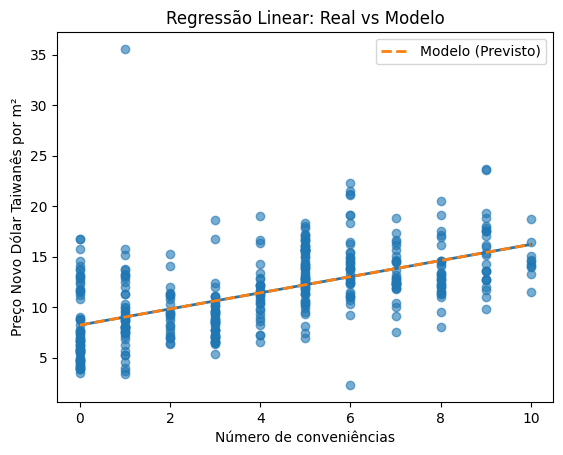

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()

# regplot (dados + tendência automática)
sns.regplot(
    x="n_convenience",
    y="price_twd_msq",
    data=df,
    ci=None,
    scatter_kws={'alpha': 0.6},
    line_kws={'linewidth': 2}
)

# ordenar para linha ficar correta
df_sorted = df.sort_values('n_convenience')
y_pred = price_twd_msq_pred[df_sorted.index]

# linha do modelo (vermelha)
plt.plot(
    df_sorted['n_convenience'],
    y_pred,
    linestyle='--',
    linewidth=2,
    label='Modelo (Previsto)'
)

# labels
plt.title('Regressão Linear: Real vs Modelo')
plt.xlabel('Número de conveniências')
plt.ylabel('Preço Novo Dólar Taiwanês por m²')

plt.legend()
plt.show()

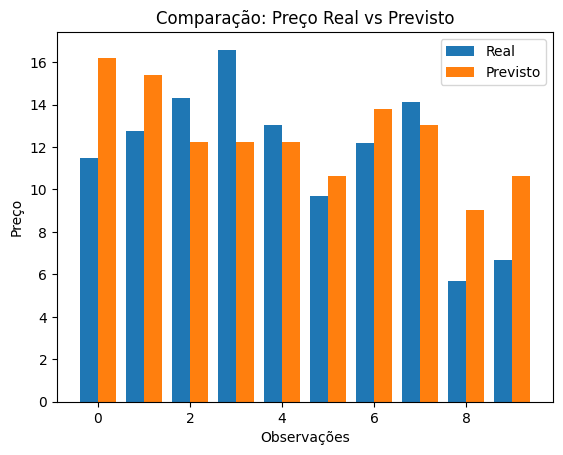

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# pegar só alguns dados (senão fica poluído)
df_sample = df.head(10)

y_real = df_sample['price_twd_msq']
y_pred = price_twd_msq_pred[df_sample.index]

x = np.arange(len(df_sample))

plt.figure()

# barras lado a lado
plt.bar(x - 0.2, y_real, width=0.4, label='Real')
plt.bar(x + 0.2, y_pred, width=0.4, label='Previsto')

# labels
plt.xlabel('Observações')
plt.ylabel('Preço')
plt.title('Comparação: Preço Real vs Previsto')

plt.legend()

plt.show()

## 📊 Análise do Modelo de Regressão Linear

### 🔹 1. Relação entre Variáveis (Gráfico de Dispersão + Regressão)

- Existe uma **relação positiva** entre o número de conveniências e o preço dos imóveis  
- A linha de regressão indica uma **tendência de crescimento**  
- Porém, há **alta dispersão dos dados**, indicando que:
  - outras variáveis também devem influenciar no preço  
  - o modelo é simples (usa apenas uma variável)

---

### 🔹 2. Comparação Real vs Previsto (Gráfico de Barras)

- O modelo consegue capturar a **tendência geral dos preços**
- Em vários pontos, os valores previstos estão **próximos dos reais**
- Porém, existem diferenças visíveis:
  - alguns imóveis são **subestimados**
  - outros são **superestimados**

👉 Isso mostra que o modelo:
- não é preciso individualmente  
- mas funciona bem em nível geral  

---

### 🧠 Insight Principal

O número de conveniências impacta o preço dos imóveis, mas **não é suficiente sozinho** para explicar toda a variação dos preços.

---

### 🎯 Conclusão

O modelo de regressão linear apresenta um bom desempenho para identificar tendências gerais, mas possui limitações preditivas devido à simplicidade. Para melhorar a precisão, seria necessário incluir mais variáveis no modelo.


## Etapa adicional (PLUS): análise complementar

Este bloco extrai os coeficientes do modelo de regressão (intercepto e inclinação) e calcula previsões manualmente com base na equação linear.

Em seguida, compara essas previsões com as geradas automaticamente pelo método `.predict()`, e calcula os resíduos (diferença entre valores reais e previstos).

Por fim, organiza os resultados em um DataFrame para análise e visualização.

In [20]:
# ==============================
# 2. EXTRAIR COEFICIENTES
coeffs = modelo.params

intercept = coeffs.iloc[0]
slope = coeffs.iloc[1]

# ==============================
# 3. PREVISÃO MANUAL
price_pred_manual = intercept + slope * df['n_convenience']

# ==============================
# 4. PREVISÃO AUTOMÁTICA
price_pred_auto = modelo.predict(df)

# ==============================
# 5. DATAFRAME FINAL
prediction_data = df.assign(
    price_pred_manual=price_pred_manual,
    price_pred_auto=price_pred_auto,
    residuo=df['price_twd_msq'] - price_pred_auto
)

# ==============================
# 6. VISUALIZAR
print(prediction_data.head())

   dist_to_mrt_m  n_convenience house_age_years  price_twd_msq  \
0       84.87882             10        30 to 45      11.467474   
1      306.59470              9        15 to 30      12.768533   
2      561.98450              5         0 to 15      14.311649   
3      561.98450              5         0 to 15      16.580938   
4      390.56840              5         0 to 15      13.040847   

   price_pred_manual  price_pred_auto   residuo  
0          16.205035        16.205035 -4.737561  
1          15.406955        15.406955 -2.638422  
2          12.214636        12.214636  2.097013  
3          12.214636        12.214636  4.366302  
4          12.214636        12.214636  0.826211  


Este código calcula o RMSE (Root Mean Squared Error), uma métrica de avaliação para modelos de regressão.

O RMSE mede a magnitude média do erro entre os valores reais (`y_true`) e os valores previstos (`y_pred`), penalizando erros maiores devido ao termo ao quadrado.

A opção `squared=False` retorna a raiz do erro quadrático médio, mantendo a unidade original da variável alvo.

Quanto menor o RMSE, melhor o desempenho do modelo.

In [23]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(df['price_twd_msq'], price_pred_auto)
rmse = np.sqrt(mse)

print(f'RMSE: {rmse:.2f}')

RMSE: 3.38


### regressão à média

In [24]:
# Comparar valores reais vs previstos
df_check = df.assign(
    real=df['price_twd_msq'],
    previsto=price_twd_msq_pred
)

print(df_check[['real', 'previsto']].head(10))

        real   previsto
0  11.467474  16.205035
1  12.768533  15.406955
2  14.311649  12.214636
3  16.580938  12.214636
4  13.040847  12.214636
5   9.712557  10.618477
6  12.193646  13.810795
7  14.130106  13.012716
8   5.688351   9.022317
9   6.686838  10.618477


Só usa 1 variável : Ele NÃO consegue explicar tudo → puxa para média

## Avaliação do Modelo: Valores Reais vs Previstos

O gráfico compara os valores reais com os valores previstos pelo modelo.

- **A linha diagonal** representa o cenário ideal, onde o modelo acerta perfeitamente (valor previsto = valor real).
- **A linha de tendência** mostra como o modelo realmente está se comportando nas previsões.

### Interpretação

- Quanto mais próximos os pontos estiverem da linha diagonal, melhor o modelo.
- Diferenças entre a linha de tendência e a linha ideal indicam erros sistemáticos.
- Quando a linha de tendência é mais “suave”, isso indica regressão à média, onde o modelo reduz valores extremos.

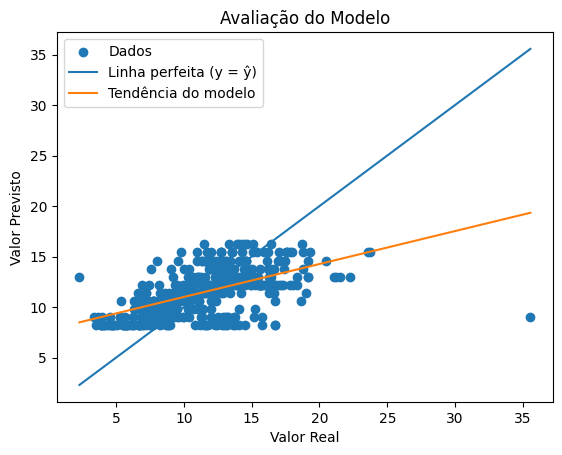

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# scatter (dados)
plt.scatter(
    df['price_twd_msq'],
    price_twd_msq_pred,
    label='Dados'
)

# linha perfeita
min_val = df['price_twd_msq'].min()
max_val = df['price_twd_msq'].max()

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    label='Linha perfeita (y = ŷ)' # modelo ideal (sem erro)
)

# linha de regressão
coef = np.polyfit(df['price_twd_msq'], price_twd_msq_pred, 1)
linha = np.poly1d(coef)

x_vals = np.linspace(min_val, max_val, 100)

plt.plot(
    x_vals,
    linha(x_vals),
    label='Tendência do modelo' # como o modelo realmente está prevendo
)

# labels
plt.xlabel('Valor Real')
plt.ylabel('Valor Previsto')
plt.title('Avaliação do Modelo')

# 🔥 legenda
plt.legend()

plt.show()